# PYTHON DATA ANALYTICS WEEK 3 - ASSIGNMENT


# PART A - Theory
### 1.	What is Data Analytics?
#### Question:
Explain what data analytics is and why businesses use it.
#### Solution:
Data analytics is the process of examining raw data to find patterns, trends, and useful information that can guide decisions. 
Businesses use it because gut-feeling decisions are risky analytics lets them base choices (pricing, staffing, marketing, and inventory) on evidence from their own data rather than guesswork.

### 2.	The Data Analytics Process
#### Question:
List and briefly explain the main stages of a typical data analytics process.
#### Solution:
a)	Defining the problem - Deciding exactly what question you're trying to answer.
b)	Collecting data - Gathering the raw data needed (databases, CSVs, APIs, surveys).
c)	Understanding/exploring the data - Getting a first look: what columns exist, what types of data, how big is it.
d)	Cleaning the data - Fixing errors, missing values, duplicates, inconsistent formatting.
e)	Transforming the data - Reshaping it into a more useful form (new columns, aggregations, type conversions).
f)	Analyzing the data - Calculating statistics, finding patterns and relationships.
g)	Visualizing the data - Turning numbers into charts so that the patterns are easier to see.
h)	Communicating insights - Presenting findings in a way decision-makers can act on.

### 3.	Data Cleaning
#### Question: What is data cleaning?
Give at least four examples of problems that may need to be fixed during data cleaning.

#### Solution: 
Data cleaning is the process of fixing or removing incorrect, incomplete, or inconsistent data before analysis. 
Examples of problems it fixes as below:
a)	Missing values (blank cells)
b)	Duplicate rows
c)	Inconsistent formatting (e.g. "Kenya" vs "kenya" vs "KE" vs “KENYA”)
d)	Incorrect data types (numbers stored as text)
e)	Outliers or clearly impossible values (e.g. age = 250)
f)	Extra whitespace in text fields
g)	Inconsistent date formats
h)	Misspelled category names (e.g. "Electronic" vs "Electronics")

### 4.	Why is Data Cleaning Important?
#### Question:
What can happen if you analyze a dataset without properly checking and cleaning it?

#### Solution: 
If you analyze dirty data, your results can be misleading or completely wrong, duplicates can inflate totals, missing values can skew averages, and inconsistent categories can split what should be one group into several. Decisions made on bad analysis can cost a business money or credibility.

### 5.	Mean vs Median
#### Question:
Explain the difference between the mean and median.
Give an example of a situation where the median might be more useful than the mean.

#### Solution:
The Mean is the arithmetic average (sum of values ÷ count). 
The Median is the middle value when data is sorted. 
The median is more useful when data has outliers or is skewed. For example, average income in a country is often better represented by the median, because a few billionaires would drag the mean way up and misrepresent what a "typical" person earns.

### 6.	Bar Chart vs Histogram
#### Question:
What is the difference between a bar chart and a histogram?
Give one example of when you would use each.
#### Solution:
A bar chart compares distinct categories, for example sales by product type.
A histogram shows the distribution of a single numerical variable by grouping values into ranges, for example how many transactions fell between Ksh. 0–50, Ksh. 50–100, etc. 
Use a bar chart for categories, a histogram for spread/frequency of numbers.

### 7.	Choosing a Visualization
#### Question:
Which visualization would you choose for each situation?

#### Solution:
a)	Comparing revenue between hotel types →Bar chart to comparing distinct categories.
b)	Sales changing over months → Line chart for trend over time.
c)	Distribution of transaction amounts → Histogram for spread of one numeric variable.
d)	Relationship between advertising spend and sales → Scatter plot for relationship between two numeric variables.


In [1]:
#Import Pandas
import pandas as pd

In [2]:
#Loading the CSV
df = pd.read_csv("C:/Users/hp/Documents/Python For Data Analyst and Data Apps/Dirty cafe sales/dirty_cafe_sales.csv")

## Inspect Data

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,08/09/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,16/05/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,19/07/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,27/04/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,11/06/2023


In [4]:
df.shape

(10000, 8)

In [5]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [7]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

### Inspected Commands Meaning
df.head() — previews the first 5 rows so you can see what the raw data actually looks like.
df.shape — returns (10000, 8): 10,000 transactions across 8 columns.
df.columns — lists the 8 column names (Transaction ID, Item, Quantity, etc.).
df.info() — shows each column's data type and non-null count. Here, every column shows as object (text), even numeric-looking ones like Quantity and Total Spent — which is a red flag that they need cleaning before we can do math on them.
df.dtypes — confirms this: everything is currently stored as text/object, not proper numbers.

In [8]:
# Missing Values
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

#### Explanation of df.isnull().sum(): 
These counts how many missing (null) values exist in each column. With this high count on the columns with missing values, it needs cleaning.

Real counts from this dataset: Item has 333 missing, Quantity has 138, Price Per Unit has 179, Total Spent has 173, Payment Method has 2,579, Location has 3,265, Transaction Date has 159. Location and Payment Method are the most incomplete over a quarter of Location is missing, so any analysis by location needs to account for that.

In [9]:
# Duplicates
df.duplicated().sum()

np.int64(0)

#### Explanation of df.duplicated().sum(): 
This returns 0. No fully duplicate rows in the dataset. Duplicates are still worth checking for generally, though, because they'd inflate totals (e.g. double-counting the same sale as two).

In [10]:
df["Item"].unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str

In [11]:
df["Item"].nunique()

10

#### Explanation: 
.unique() lists the actual distinct values: Coffee, Cake, Cookie, Salad, Smoothie, Sandwich, Juice, Tea — plus the placeholders "UNKNOWN", "ERROR", and actual missing (NaN) values.
.nunique() returns 10 (it doesn't count NaN as a category). Notice "ERROR" and "UNKNOWN" are text values, not true missing data — that's a data-cleaning issue you'd normally convert to NaN before analyzing.

## Frequency Analysis

In [12]:
df["Payment Method"].value_counts()

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

In [13]:
df["Payment Method"].value_counts().idxmax()

'Digital Wallet'

#### Exaplanation on df["Payment Method"].value_counts() & df["Payment Method"].value_counts().idxmax()

Results: Digital Wallet (2,291), Credit Card (2,273), Cash (2,258), then the placeholders "ERROR" (306) and "UNKNOWN" (293). idxmax() returns "Digital Wallet". It gives you just the label of the most frequent category, not the count itself.


# PART C — Basic Statistics

Total Spent is stored as text with "ERROR" mixed in, so Let's convert it to numeric first.

In [14]:
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

df["Total Spent"].sum()
df["Total Spent"].mean()
df["Total Spent"].median()
df["Total Spent"].min()
df["Total Spent"].max()

np.float64(25.0)

In [15]:
df["Total Spent"].sum()

np.float64(84763.5)

In [16]:
df["Total Spent"].mean()

np.float64(8.924352495262161)

In [17]:
df["Total Spent"].median()

np.float64(8.0)

In [18]:
df["Total Spent"].min()

np.float64(1.0)

In [19]:
df["Total Spent"].max()

np.float64(25.0)

My Actual Results are:
Sum: 84,763.50
Mean: 8.92
Median: 8.00
Min: 1.00
Max: 25.00

The average transaction value is 8.92, and the median is 8.00, which are very close to each other. This suggests transaction amounts are fairly evenly distributed without extreme high-value outliers dragging the average up. The minimum spend is 1.00 and the maximum is 25.00, a fairly narrow, realistic range for cafe purchases.

# PART D - GroupBy

In [20]:
df.groupby("Item")["Total Spent"].sum()
df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

Item
Salad       16605.0
Sandwich    12956.0
Smoothie    12556.0
Juice        9984.0
Cake         9933.0
Coffee       6784.0
Tea          4735.5
Cookie       3070.0
UNKNOWN      2757.5
ERROR        2453.5
Name: Total Spent, dtype: float64

Salad has the highest total revenue (16,605), while Cookie has the lowest among real items (3,070)

"UNKNOWN" and "ERROR" aren't real items, they are data quality issues that should ideally be cleaned out before drawing conclusions. 
The business insight: Salad and Sandwich are the strongest revenue drivers here, which is a bit unusual for a "cafe". 
It may be worth checking whether pricing or high volume is driving this, and whether Cookie is underpriced, low in stock, or just less popular.

# PART E - Visualization

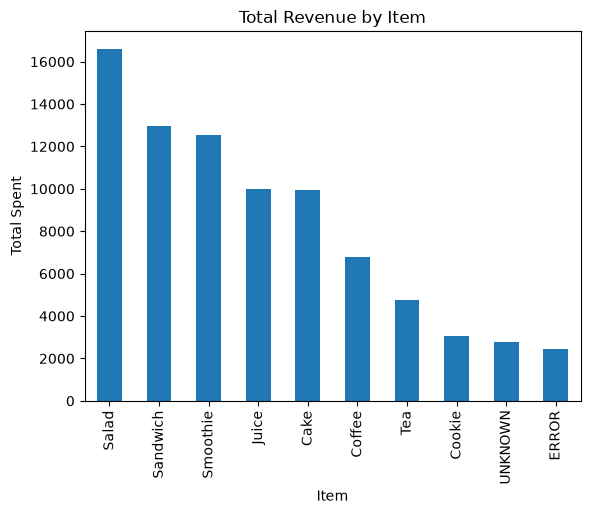

In [21]:
import matplotlib.pyplot as plt

# 1. Bar chart — revenue by item
df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Total Revenue by Item")
plt.xlabel("Item")
plt.ylabel("Total Spent")
plt.show()

Insight: Salad and Sandwich generate noticeably more revenue than Cookie or Tea, suggesting the menu's higher-priced items are the main revenue drivers.

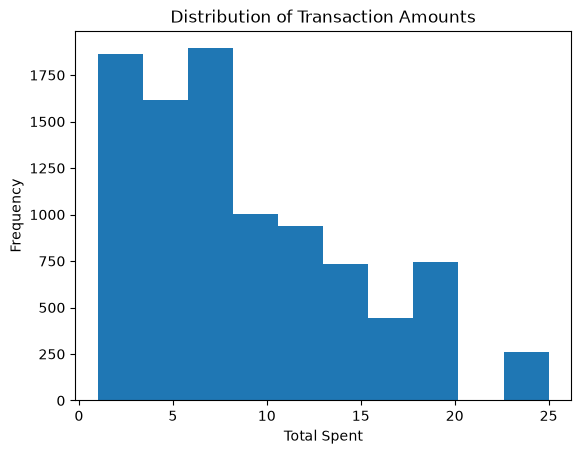

In [22]:
# 2. Histogram — distribution of transaction amounts
df["Total Spent"].plot(kind="hist", bins=10)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

Insight: 
Most transactions cluster in the lower-to-mid range, with fewer high-value transactions near the 25.00 max, typical of everyday small purchases like a cafe.

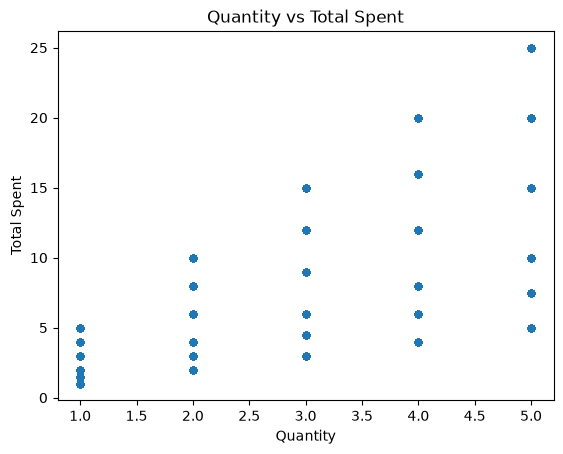

In [23]:
# 3. Scatter plot — quantity vs total spent
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

df.plot(kind="scatter", x="Quantity", y="Total Spent")
plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")
plt.show()

Insight: 
There is a general upward relationship, higher quantities tend to correspond to higher total spend, which makes sense since total spent is quantity × price per unit.

# PART F - DATA ANALYTICS THINKING

### Question 1
What is the difference between?
"I wrote Python code."
And
"I performed data analysis using Python."
#### Solution:
"I wrote Python code" describes the technical act of producing working code. 
"I performed data analysis using Python" describes the purpose, using that code as a tool to answer a real question. The first is about syntax; the second is about insight.

### Question 2
Why should a data analyst understand the business question before starting to analyze a dataset?
#### Solution:
Understanding the business question first ensures the analysis actually answers something useful. Without it, you risk producing technically correct numbers and charts that don't help anyone make a decision.

### Question 3
Why is it not enough to simply create charts?
What should an analyst do after creating a visualization?
#### Solution:
Charts alone don't explain why something is happening or what to do about it. After creating a visualization, an analyst should interpret it, explain the pattern, connect it to the business question, and suggest what action it points to.

